
# Reproduction: bilinear SME vs OLS confidence diameters

1. gen structured bilinear system：diagonal `A`，strictly lower triangular `B_i`；
2. gen bounded input/noise，simulate trajectory；
3. use support-function LP to simulate SME feasible set's Frobenius diameter；
4. use the same repeated trajectories to compute OLS confidence diameter；
5. draw SME and OLS 90/10/1 confidence diameter curves。



In [16]:

from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Literal
import json
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.optimize import linprog
from scipy.stats import t as student_t
from scipy.stats import chi2

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (4.5, 3.5),
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7,
})


In [17]:

@dataclass
class ExperimentConfig:
    # Dimensions
    n: int = 5
    m: int = 4

    # Seeds
    seed_system: int = 0
    seed_input: int = 1
    seed_noise: int = 2
    seed_directions: int = 10_000

    # Time grid: Fig. 1 style range. Use 10..500 if you want the old exploratory range.
    t_min: int = 25
    t_max: int = 200
    t_step: int = 5

    # Monte Carlo and SME approximation settings
    n_repeats: int = 10
    sme_n_directions: int = 120  # code also uses the negative directions, so 2x LP solves

    # Data generation
    u_bound: float = 2.0
    w_bound: float = 1.0
    noise_kind: Literal["gaussian", "laplace"] = "gaussian"

    # SME settings
    w_max_for_sme: float = 1.0
    theta_bound: float | None = 100.0
    per_time_scaling: bool = True

    # OLS confidence diameters. confidence = 1 - delta.
    # ols_confidences: tuple[float, ...] = (0.90, 0.80, 0.70, 0.10)
    ols_confidences: tuple[float, ...] = (0.90, 0.10, 0.01)
    ols_ridge: float = 1e-2
    ols_sigma: float = 1.0

    # Error bands across repeated trajectories, not the OLS confidence level.
    summary_band_confidence: float = 0.90

    # Output/cache
    output_dir: str = "outputs"
    cache_name: str = "diameter_results_clean_multi_ols_v3.pkl"
    figure_stem: str = "diameter_fig_multi_ols"


QUICK_RUN = True

base_cfg = ExperimentConfig()

if QUICK_RUN:
    cfg = ExperimentConfig(
        t_min=50,
        t_max=500,
        t_step=25,
        n_repeats=12,
        sme_n_directions=80,
        u_bound=base_cfg.u_bound,
        noise_kind=base_cfg.noise_kind,
        cache_name="quick_diameter_results_clean_multi_ols_v3.pkl",
        figure_stem="quick_diameter_fig_multi_ols",
    )
else:
    cfg = base_cfg

OUT_DIR = Path(cfg.output_dir)
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = OUT_DIR / cfg.cache_name
FORCE_RECOMPUTE = True

print(cfg)
print("cache:", CACHE_PATH)


ExperimentConfig(n=5, m=4, seed_system=0, seed_input=1, seed_noise=2, seed_directions=10000, t_min=50, t_max=500, t_step=25, n_repeats=12, sme_n_directions=80, u_bound=2.0, w_bound=1.0, noise_kind='gaussian', w_max_for_sme=1.0, theta_bound=100.0, per_time_scaling=True, ols_confidences=(0.9, 0.1, 0.01), ols_ridge=0.01, ols_sigma=1.0, summary_band_confidence=0.9, output_dir='outputs', cache_name='quick_diameter_results_clean_multi_ols_v3.pkl', figure_stem='quick_diameter_fig_multi_ols')
cache: outputs/quick_diameter_results_clean_multi_ols_v3.pkl



## 1. System, input/noise, and trajectory utilities


In [18]:

def spectral_radius(M: np.ndarray) -> float:
    return float(np.max(np.abs(np.linalg.eigvals(M))))


def make_A(n: int, rng: np.random.Generator) -> np.ndarray:
    diag = rng.uniform(-1.0, 1.0, size=n)
    diag[0] = 1.0
    return np.diag(diag)


def make_B_list(n: int, m: int, rng: np.random.Generator) -> list[np.ndarray]:
    return [np.tril(rng.normal(0.0, 1.0, size=(n, n)), k=-1) for _ in range(m)]


def build_tildeA(A: np.ndarray, B_list: list[np.ndarray], sigma_u2: float = 1.0) -> np.ndarray:
    out = np.kron(A, A)
    for B in B_list:
        out = out + sigma_u2 * np.kron(B, B)
    return out


def generate_system(cfg: ExperimentConfig) -> tuple[np.ndarray, list[np.ndarray], dict]:
    rng = np.random.default_rng(cfg.seed_system)
    A = make_A(cfg.n, rng)
    B_list = make_B_list(cfg.n, cfg.m, rng)
    A_tilde = build_tildeA(A, B_list, sigma_u2=1.0)
    info = {
        "rho_A": spectral_radius(A),
        "rho_tilde": spectral_radius(A_tilde),
        "strict_lower_B": [bool(np.allclose(B, np.tril(B, k=-1))) for B in B_list],
    }
    return A, B_list, info


def sample_truncated_gaussian_linf(T: int, dim: int, bound: float, rng: np.random.Generator) -> np.ndarray:
    out = np.empty((T, dim), dtype=float)
    filled = 0
    batch = max(4096, 4 * T)
    while filled < T:
        X = rng.standard_normal(size=(batch, dim))
        keep = X[np.max(np.abs(X), axis=1) <= bound]
        k = min(len(keep), T - filled)
        if k:
            out[filled:filled + k] = keep[:k]
            filled += k
    return out


def sample_truncated_laplace_linf(T: int, dim: int, bound: float, rng: np.random.Generator) -> np.ndarray:
    out = np.empty((T, dim), dtype=float)
    filled = 0
    batch = max(4096, 8 * T)
    while filled < T:
        X = rng.laplace(loc=0.0, scale=1.0, size=(batch, dim))
        keep = X[np.max(np.abs(X), axis=1) <= bound]
        k = min(len(keep), T - filled)
        if k:
            out[filled:filled + k] = keep[:k]
            filled += k
    return out


def generate_inputs_and_noises(cfg: ExperimentConfig) -> tuple[np.ndarray, np.ndarray]:
    total_T = cfg.n_repeats * cfg.t_max
    U = sample_truncated_gaussian_linf(total_T, cfg.m, cfg.u_bound, np.random.default_rng(cfg.seed_input))
    rng_w = np.random.default_rng(cfg.seed_noise)
    if cfg.noise_kind == "gaussian":
        W = sample_truncated_gaussian_linf(total_T, cfg.n, cfg.w_bound, rng_w)
    elif cfg.noise_kind == "laplace":
        W = sample_truncated_laplace_linf(total_T, cfg.n, cfg.w_bound, rng_w)
    else:
        raise ValueError("noise_kind must be 'gaussian' or 'laplace'.")
    return U, W


def simulate_bilinear(A: np.ndarray, B_list: list[np.ndarray], U: np.ndarray, W: np.ndarray, x0=None) -> np.ndarray:
    T, m = U.shape
    n = A.shape[0]
    assert W.shape == (T, n)
    assert len(B_list) == m
    if x0 is None:
        x0 = np.zeros(n)
    X = np.zeros((T + 1, n), dtype=float)
    X[0] = np.asarray(x0, dtype=float).reshape(n)
    for t in range(T):
        x_t = X[t]
        bilinear = sum(U[t, i] * (B_list[i] @ x_t) for i in range(m))
        X[t + 1] = A @ x_t + bilinear + W[t]
    return X


def build_Z(X: np.ndarray, U: np.ndarray) -> np.ndarray:
    T, m = U.shape
    n = X.shape[1]
    assert X.shape[0] == T + 1
    Z = np.zeros((T, n + m * n), dtype=float)
    for t in range(T):
        Z[t, :n] = X[t]
        Z[t, n:] = np.kron(U[t], X[t])
    return Z


def theta_true_from_A_B(A: np.ndarray, B_list: list[np.ndarray]) -> np.ndarray:
    return np.hstack([A] + B_list)


A, B_list, system_info = generate_system(cfg)
Theta_true = theta_true_from_A_B(A, B_list)
print("system_info:", system_info)
print("Theta_true shape:", Theta_true.shape)


system_info: {'rho_A': 1.0, 'rho_tilde': 1.0, 'strict_lower_B': [True, True, True, True]}
Theta_true shape: (5, 25)



## 2. SME diameter by support LPs

The SME set is

\[
S_T=\{\Theta: \|x_{t+1}-\Theta z_t\|_\infty\le w_{\max},\ t=0,\ldots,T-1\}.
\]

The exact Frobenius diameter is nonconvex. Here we sample directions \(D_k\), solve support LPs over \(S_T\), and compute the largest pairwise Frobenius distance among sampled extreme points.


In [19]:

def scaled_sme_data(X: np.ndarray, U: np.ndarray, w_max: float, per_time_scaling: bool, eps: float = 1e-12):
    Z = build_Z(X, U)
    Y = X[1:]
    if per_time_scaling:
        s = np.maximum(1.0 + np.linalg.norm(Z, axis=1), eps)
        return Z / s[:, None], Y / s[:, None], (w_max / s)[:, None]
    return Z, Y, w_max * np.ones((Z.shape[0], 1))


def build_sme_lp_constraints(Zs: np.ndarray, Ys: np.ndarray, w_vec: np.ndarray) -> tuple[sparse.csr_matrix, np.ndarray]:
    T, d = Zs.shape
    n = Ys.shape[1]
    rows, cols, vals = [], [], []
    b = np.empty(2 * T * n, dtype=float)
    row = 0
    for t in range(T):
        z = Zs[t]
        w = float(w_vec[t, 0])
        for j in range(n):
            start = j * d
            # Theta[j] @ z <= y_j + w
            cols.extend(range(start, start + d))
            rows.extend([row] * d)
            vals.extend(z)
            b[row] = Ys[t, j] + w
            row += 1
            # -Theta[j] @ z <= -y_j + w
            cols.extend(range(start, start + d))
            rows.extend([row] * d)
            vals.extend(-z)
            b[row] = -Ys[t, j] + w
            row += 1
    A_ub = sparse.coo_matrix((vals, (rows, cols)), shape=(2 * T * n, n * d)).tocsr()
    return A_ub, b


def random_unit_directions(n_directions: int, shape: tuple[int, int], rng: np.random.Generator) -> np.ndarray:
    n, d = shape
    G = rng.standard_normal(size=(n_directions, n * d))
    G /= np.linalg.norm(G, axis=1, keepdims=True) + 1e-18
    return G.reshape(n_directions, n, d)


def approximate_sme_diameter_fro(
    X: np.ndarray,
    U: np.ndarray,
    directions: np.ndarray,
    w_max: float = 1.0,
    theta_bound: float | None = 100.0,
    per_time_scaling: bool = True,
) -> tuple[float, dict]:
    Zs, Ys, w_vec = scaled_sme_data(X, U, w_max=w_max, per_time_scaling=per_time_scaling)
    A_ub, b_ub = build_sme_lp_constraints(Zs, Ys, w_vec)
    T, d = Zs.shape
    n = Ys.shape[1]
    n_vars = n * d
    bounds = [(None, None)] * n_vars if theta_bound is None else [(-theta_bound, theta_bound)] * n_vars
    direction_vecs = np.concatenate([directions, -directions], axis=0).reshape(-1, n_vars)

    points = np.empty((direction_vecs.shape[0], n_vars), dtype=float)
    support_values = np.empty(direction_vecs.shape[0], dtype=float)
    for k, direction in enumerate(direction_vecs):
        result = linprog(c=-direction, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
        if not result.success:
            raise RuntimeError(f"SME support LP failed at direction {k}: {result.message}")
        points[k] = result.x
        support_values[k] = -result.fun

    norms2 = np.sum(points ** 2, axis=1)
    dist2 = norms2[:, None] + norms2[None, :] - 2.0 * (points @ points.T)
    diameter = float(np.sqrt(np.maximum(dist2, 0.0).max()))
    info = {
        "T": int(T),
        "num_support_lps": int(direction_vecs.shape[0]),
        "support_min": float(support_values.min()),
        "support_max": float(support_values.max()),
    }
    return diameter, info


## 3. OLS confidence diameters

For OLS, the plotted curves are confidence-region diameters. The confidence level enters as \(\delta=1-\text{confidence}\). The default curves are 90%, 10%, 1%.

Following the baseline construction used in the SME paper, for each confidence level we compute 2 OLS diameter estimates/bounds and plot their minimum:

1. a Lemma-E.3-style two-scale LSE bound with an optimized eigenspace split;
2. a classical/asymptotic chi-square OLS ellipsoid diameter.


In [ ]:

def theta_star_matrix(A: np.ndarray, B_list: list[np.ndarray]) -> np.ndarray:
    """Pack Θ* = [A, B1, ..., Bm]."""
    return np.concatenate([A] + list(B_list), axis=1)


def estimate_noise_variance(X: np.ndarray, U: np.ndarray, ridge: float = 1e-2) -> float:
    """Empirical residual variance from the OLS fit. Used only as a scale estimate for plotting."""
    Z = build_Z(X, U)
    Y = X[1:]
    Theta_hat, _ = identify_theta_ols(X, U, ridge=ridge)
    residual = Y - Z @ Theta_hat.T
    n_outputs = Y.shape[1]
    d = Z.shape[1]
    dof = max(Y.size - n_outputs * d, 1)
    return max(float(np.sum(residual ** 2) / dof), 1e-12)


def two_scale_lse_diameter_from_gram(
    Gamma: np.ndarray,
    n_outputs: int,
    confidence: float,
    sigma: float = 1.0,
    eps: float = 1e-12,
) -> tuple[float, float, dict]:
    """
    Lemma-E.3-style two-scale OLS diameter.

    This follows the experimental construction in the SME paper: diagonalize the
    empirical covariance Gamma = G M G^T, choose a block projection P0 in this
    diagonal basis, optimize over the block size p, and use the best-case
    cross-term simplification. Eigenvalues are sorted in ascending order so that
    the P-block corresponds to the low-excitation directions and lambda_1 <= lambda_2.
    """
    delta = 1.0 - float(confidence)
    if not (0.0 < delta < 1.0):
        raise ValueError("confidence must be in (0, 1).")

    Gamma = 0.5 * (Gamma + Gamma.T)
    d = Gamma.shape[0]
    eigvals, eigvecs = np.linalg.eigh(Gamma)
    order = np.argsort(eigvals)  # ascending: low-excitation directions first
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    radii, metas = [], []
    for p in range(1, d):
        low = eigvals[:p]
        high = eigvals[p:]
        lambda_1 = float(np.min(low))
        lambda_2 = float(np.min(high))
        if lambda_1 <= eps or lambda_2 <= eps or lambda_1 > lambda_2:
            continue

        # In the diagonalized basis, the cross block is zero. Following the
        # best-case simplification after Lemma E.3, we take nu/lambda_1 = 1.
        kappa_1 = max(float(np.max(low) / lambda_1), eps)
        kappa_2 = max(float(np.max(high) / lambda_2), eps)

        log1 = np.log(3.0 * n_outputs * d * kappa_1 / delta)
        log2 = np.log(3.0 * n_outputs * d * kappa_2 / delta)
        term1 = 12.0 * n_outputs * p * kappa_1 * log1 / lambda_1
        term2 = 48.0 * n_outputs * (d - p) * kappa_2 * log2 / lambda_2
        bound_sq = float(sigma ** 2 * (term1 + term2))

        if np.isfinite(bound_sq) and bound_sq > 0:
            radii.append(float(np.sqrt(bound_sq)))
            metas.append({
                "source": "Lemma E.3 two-scale",
                "p": p,
                "lambda_1": lambda_1,
                "lambda_2": lambda_2,
                "kappa_1": kappa_1,
                "kappa_2": kappa_2,
            })

    if not radii:
        return float("inf"), float("inf"), {"source": "Lemma E.3 two-scale", "reason": "no finite split"}

    best = int(np.argmin(radii))
    radius = float(radii[best])
    details = dict(metas[best])
    details.update({"radius": radius, "diameter": 2.0 * radius, "confidence": float(confidence)})
    return 2.0 * radius, radius, details


def abbasi_yadkori_diameter_from_gram(
    Gamma: np.ndarray,
    theta_star: np.ndarray,
    confidence: float,
    lambda_reg: float = 0.1,
    noise_proxy: float = 1.0,
    eps: float = 1e-12,
) -> tuple[float, float, dict]:
    """
    Abbasi--Yadkori-style self-normalized OLS confidence diameter.

    We use the standard ellipsoid radius beta_T and convert it to a Frobenius
    diameter through lambda_min(V_T). This is used only as a plotting baseline;
    the final OLS diameter is later combined with Lemma E.3 and the classical ellipsoid by taking the minimum.
    """
    delta = 1.0 - float(confidence)
    if not (0.0 < delta < 1.0):
        raise ValueError("confidence must be in (0, 1).")

    Gamma = 0.5 * (Gamma + Gamma.T)
    d = Gamma.shape[0]
    V = Gamma + lambda_reg * np.eye(d)
    eigvals = np.linalg.eigvalsh(V)
    lambda_min = max(float(np.min(eigvals)), eps)

    # log det(V / lambda_reg I) in a numerically stable form.
    log_det_ratio = float(np.sum(np.log(np.maximum(eigvals, eps))) - d * np.log(lambda_reg))
    S = float(np.linalg.norm(theta_star, ord="fro"))

    beta = noise_proxy * np.sqrt(max(log_det_ratio + 2.0 * np.log(1.0 / delta), 0.0)) + np.sqrt(lambda_reg) * S
    radius = float(beta / np.sqrt(lambda_min))
    diameter = 2.0 * radius
    details = {
        "source": "Abbasi-Yadkori",
        "lambda_reg": lambda_reg,
        "noise_proxy": noise_proxy,
        "S": S,
        "lambda_min_V": lambda_min,
        "beta": float(beta),
        "radius": radius,
        "diameter": diameter,
        "confidence": float(confidence),
    }
    return diameter, radius, details


def classical_ols_ellipsoid_diameter_from_gram(
    Gamma: np.ndarray,
    n_outputs: int,
    confidence: float,
    sigma: float = 1.0,
    ridge: float = 1e-2,
    eps: float = 1e-12,
) -> tuple[float, float, dict]:
    """
    Classical/asymptotic OLS confidence ellipsoid diameter.

    This uses the Gaussian/asymptotic approximation
        vec(Theta_hat - Theta*) ~ N(0, sigma^2 (Gamma^{-1} ⊗ I_n)),
    so the c-level ellipsoid has chi-square threshold chi2.ppf(c, p), where
    p = n_outputs * regressor_dimension. Its Euclidean/Frobenius diameter is
        2 * sigma * sqrt(chi2.ppf(c, p) / lambda_min(Gamma)).

    Unlike the high-probability theoretical bounds above, this diameter goes to
    zero as confidence -> 0. It is included only as an additional empirical curve.
    """
    c = float(confidence)
    if not (0.0 < c < 1.0):
        raise ValueError("confidence must be in (0, 1).")

    Gamma = 0.5 * (Gamma + Gamma.T)
    d = Gamma.shape[0]
    V = Gamma + ridge * np.eye(d)
    eigvals = np.linalg.eigvalsh(V)
    lambda_min = max(float(np.min(eigvals)), eps)

    p_total = int(n_outputs * d)
    q = float(chi2.ppf(c, df=p_total))
    q = max(q, 0.0)
    radius = float(sigma * np.sqrt(q / lambda_min))
    diameter = 2.0 * radius
    details = {
        "source": "Classical chi-square OLS ellipsoid",
        "p_total": p_total,
        "chi2_quantile": q,
        "lambda_min_V": lambda_min,
        "sigma": sigma,
        "ridge": ridge,
        "radius": radius,
        "diameter": diameter,
        "confidence": c,
    }
    return diameter, radius, details


def identify_theta_ols(X: np.ndarray, U: np.ndarray, ridge: float = 1e-2) -> tuple[np.ndarray, dict]:
    Z = build_Z(X, U)
    Y = X[1:]
    n = Y.shape[1]
    d = Z.shape[1]
    Gamma = Z.T @ Z + ridge * np.eye(d)
    Theta_T = np.linalg.solve(Gamma, Z.T @ Y)
    Theta_hat = Theta_T.T
    residual = Y - Z @ Theta_hat.T
    info = {
        "mse": float(np.mean(residual ** 2)),
        "max_abs_residual": float(np.max(np.abs(residual))),
        "rank_Gamma": int(np.linalg.matrix_rank(Gamma)),
        "cond_Gamma": float(np.linalg.cond(Gamma)),
        "n": n,
        "d": d,
    }
    return Theta_hat, info


def ols_confidence_diameters(
    X: np.ndarray,
    U: np.ndarray,
    cfg: ExperimentConfig,
    theta_star: np.ndarray,
) -> dict[float, float]:
    """Return min{Lemma E.3, classical chi-square ellipsoid} for each confidence level."""
    Z = build_Z(X, U)
    Gamma = Z.T @ Z
    n_outputs = X.shape[1]

    # Keep the scale fixed by default. If desired, replace cfg.ols_sigma with
    # np.sqrt(estimate_noise_variance(X, U, ridge=cfg.ols_ridge)).
    sigma = cfg.ols_sigma

    out = {}
    for conf in cfg.ols_confidences:
        diam_e3, _, _ = two_scale_lse_diameter_from_gram(
            Gamma, n_outputs=n_outputs, confidence=conf, sigma=sigma
        )
        diam_classical, _, _ = classical_ols_ellipsoid_diameter_from_gram(
            Gamma,
            n_outputs=n_outputs,
            confidence=conf,
            sigma=sigma,
            ridge=cfg.ols_ridge,
        )
        out[float(conf)] = min(diam_e3, diam_classical)
    return out



## 4. Experiment loop and cache


In [21]:

def config_signature(cfg: ExperimentConfig) -> str:
    return json.dumps(asdict(cfg), sort_keys=True, default=str)


def run_experiment(cfg: ExperimentConfig) -> dict:
    A, B_list, system_info = generate_system(cfg)
    theta_star = theta_star_matrix(A, B_list)
    U_all, W_all = generate_inputs_and_noises(cfg)
    T_values = np.arange(cfg.t_min, cfg.t_max + 1, cfg.t_step, dtype=int)
    d = cfg.n + cfg.m * cfg.n
    rng_dir = np.random.default_rng(cfg.seed_directions)
    directions = random_unit_directions(cfg.sme_n_directions, (cfg.n, d), rng_dir)

    sme_diameter = np.full((cfg.n_repeats, len(T_values)), np.nan)
    ols_diameter_by_confidence = {
        conf: np.full((cfg.n_repeats, len(T_values)), np.nan) for conf in cfg.ols_confidences
    }

    print("system_info:", system_info)
    print("max |U|:", float(np.max(np.abs(U_all))), "max |W|:", float(np.max(np.abs(W_all))))
    start_time = time.time()

    for rep in range(cfg.n_repeats):
        start = rep * cfg.t_max
        end = start + cfg.t_max
        U_rep = U_all[start:end]
        W_rep = W_all[start:end]
        X_rep = simulate_bilinear(A, B_list, U_rep, W_rep, x0=np.zeros(cfg.n))
        print(f"Repeat {rep + 1}/{cfg.n_repeats}")

        for idx, T_cur in enumerate(T_values):
            X_T = X_rep[:T_cur + 1]
            U_T = U_rep[:T_cur]
            sme_diameter[rep, idx], _ = approximate_sme_diameter_fro(
                X_T,
                U_T,
                directions=directions,
                w_max=cfg.w_max_for_sme,
                theta_bound=cfg.theta_bound,
                per_time_scaling=cfg.per_time_scaling,
            )
            ols_diams = ols_confidence_diameters(X_T, U_T, cfg, theta_star=theta_star)
            for conf, val in ols_diams.items():
                ols_diameter_by_confidence[conf][rep, idx] = val

        print(f"  elapsed: {(time.time() - start_time) / 60:.2f} min")

    return {
        "config": asdict(cfg),
        "config_signature": config_signature(cfg),
        "A": A,
        "B_list": B_list,
        "theta_star": theta_star,
        "system_info": system_info,
        "T_values": T_values,
        "sme_diameter": sme_diameter,
        "ols_diameter_by_confidence": ols_diameter_by_confidence,
    }


def load_or_run_experiment(cfg: ExperimentConfig, cache_path: Path, force_recompute: bool = False) -> dict:
    if cache_path.exists() and not force_recompute:
        with open(cache_path, "rb") as f:
            cached = pickle.load(f)
        if cached.get("config_signature") == config_signature(cfg):
            print("Loaded cached results from", cache_path)
            return cached
        print("Cache exists but config changed; recomputing.")

    results = run_experiment(cfg)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(results, f)
    print("Saved results to", cache_path)
    return results


results = load_or_run_experiment(cfg, CACHE_PATH, force_recompute=FORCE_RECOMPUTE)
print("SME diameter shape:", results["sme_diameter"].shape)
print("OLS confidence levels:", list(results["ols_diameter_by_confidence"].keys()))


system_info: {'rho_A': 1.0, 'rho_tilde': 1.0, 'strict_lower_B': [True, True, True, True]}
max |U|: 1.9998224959527664 max |W|: 0.9999978905581786
Repeat 1/12
  elapsed: 1.61 min
Repeat 2/12
  elapsed: 3.24 min
Repeat 3/12
  elapsed: 4.83 min
Repeat 4/12
  elapsed: 6.40 min
Repeat 5/12
  elapsed: 8.03 min
Repeat 6/12
  elapsed: 9.65 min
Repeat 7/12
  elapsed: 11.28 min
Repeat 8/12
  elapsed: 12.97 min
Repeat 9/12
  elapsed: 14.60 min
Repeat 10/12
  elapsed: 16.19 min
Repeat 11/12
  elapsed: 17.83 min
Repeat 12/12
  elapsed: 19.44 min
Saved results to outputs/quick_diameter_results_clean_multi_ols_v3.pkl
SME diameter shape: (12, 19)
OLS confidence levels: [0.9, 0.1, 0.01]


In [22]:
def estimate_loglog_slope(T_values, y_values, T_min=None, T_max=None):
    T_values = np.asarray(T_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    mask = np.isfinite(T_values) & np.isfinite(y_values) & (T_values > 0) & (y_values > 0)
    if T_min is not None:
        mask &= T_values >= T_min
    if T_max is not None:
        mask &= T_values <= T_max

    slope, intercept = np.polyfit(np.log(T_values[mask]), np.log(y_values[mask]), 1)
    return slope, -slope


## 5. Plot

Shaded bands are Monte-Carlo bands across repeated trajectories. They are separate from the OLS confidence levels. The OLS curve labels indicate the confidence level used inside the confidence-diameter formula.


saved figure: outputs/quick_diameter_fig_multi_ols-v3-nonlg.pdf
saved figure: outputs/quick_diameter_fig_multi_ols-v3-nonlg.png


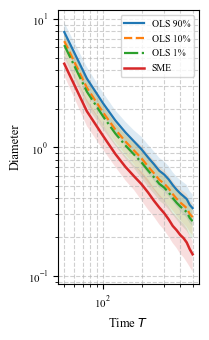

In [23]:

def mean_with_t_band(values: np.ndarray, confidence: float = 0.90) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    values = np.asarray(values, dtype=float)
    n_rep = values.shape[0]
    mean = np.nanmean(values, axis=0)
    if n_rep < 2:
        return mean, mean, mean
    sem = np.nanstd(values, axis=0, ddof=1) / np.sqrt(n_rep)
    alpha = 1.0 - confidence
    tcrit = student_t.ppf(1.0 - alpha / 2.0, df=n_rep - 1)
    half_width = tcrit * sem
    lower = np.maximum(mean - half_width, np.finfo(float).tiny)
    upper = mean + half_width
    return mean, lower, upper


def plot_diameter_results(results: dict, cfg: ExperimentConfig, plot_ols_radius: bool = False, T_max: int = 5000):

    T_values_all = np.asarray(results["T_values"], dtype=float)
    t_mask = T_values_all <= T_max
    T_values = T_values_all[t_mask]

    # T_values = results["T_values"]
    band_conf = cfg.summary_band_confidence
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    scale = 0.5 if plot_ols_radius else 1.0
    ylabel = "Radius" if plot_ols_radius else "Diameter"

    linestyles = {0.90: "-", 0.10: "--", 0.01: "-."}
    ols = results["ols_diameter_by_confidence"]
    for idx, conf in enumerate(sorted(ols.keys(), reverse=True)):
        # mean, lower, upper = mean_with_t_band(scale * ols[conf], confidence=band_conf)

        ols_values = scale * np.asarray(ols[conf], dtype=float)[..., t_mask]
        mean, lower, upper = mean_with_t_band(ols_values, confidence=band_conf)

        ax.plot(
            T_values,
            mean,
            linestyle=linestyles.get(round(conf, 2), "-"),
            linewidth=1.6,
            label=f"OLS {100 * conf:g}%",
        )
        # if idx == 0:
        if idx <=2:
            ax.fill_between(T_values, lower, upper, alpha=0.15)
        
    
    # slope, rate = estimate_loglog_slope(T_values, mean, T_min=800, T_max=3750)
    # print(f"OLS {100 * conf:g}%: slope={slope:.3f}, rate alpha={rate:.3f}")

    # sme_mean, sme_lower, sme_upper = mean_with_t_band(results["sme_diameter"], confidence=band_conf)
    sme_values = np.asarray(results["sme_diameter"], dtype=float)[..., t_mask]
    sme_mean, sme_lower, sme_upper = mean_with_t_band(sme_values, confidence=band_conf)

    # slope, rate = estimate_loglog_slope(T_values, sme_mean, T_min=800, T_max=3750)
    # print(f"SME: slope={slope:.3f}, rate alpha={rate:.3f}")


    ax.plot(T_values, sme_mean, linewidth=1.8, label="SME")
    # ax.fill_between(T_values, sme_lower, sme_upper, alpha=0.22, label=f"{int(100 * band_conf)}% Error Band for SME")
    ax.fill_between(T_values, sme_lower, sme_upper, alpha=0.15)

    ax.set_yscale("log")
    ax.set_xscale("log")

    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Time $T$")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", linestyle="--", alpha=0.6)
    ax.legend(loc="best")
    fig.tight_layout()

    out_pdf = OUT_DIR / f"{cfg.figure_stem}-v3-nonlg.pdf"
    out_png = OUT_DIR / f"{cfg.figure_stem}-v3-nonlg.png"
    # out_pdf = OUT_DIR / f"{cfg.figure_stem}-v3.pdf"
    # out_png = OUT_DIR / f"{cfg.figure_stem}-v3.png"

    fig.savefig(out_pdf, bbox_inches="tight")
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    print("saved figure:", out_pdf)
    print("saved figure:", out_png)
    return fig, ax


fig, ax = plot_diameter_results(results, cfg, plot_ols_radius=False)
plt.show()



## Result test


In [24]:

print("A =")
print(results["A"])
print("rho_tilde =", results["system_info"]["rho_tilde"])
print("SME diameter array:", results["sme_diameter"].shape)
print("OLS arrays:", {int(100 * k): v.shape for k, v in results["ols_diameter_by_confidence"].items()})


A =
[[ 1.      0.      0.      0.      0.    ]
 [ 0.     -0.4604  0.      0.      0.    ]
 [ 0.      0.     -0.9181  0.      0.    ]
 [ 0.      0.      0.     -0.9669  0.    ]
 [ 0.      0.      0.      0.      0.6265]]
rho_tilde = 1.0
SME diameter array: (12, 19)
OLS arrays: {90: (12, 19), 10: (12, 19), 1: (12, 19)}
